# Thực hành về mạng GAN

### Chuẩn bị các thư viện cần thiết

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import glob
import cv2
import torch.nn.functional as F
from torch.autograd import Variable

import torchvision
import torchvision.transforms as transforms

from torch.nn import CrossEntropyLoss, Dropout, Softmax, Linear, Conv2d, LayerNorm
import matplotlib.pyplot as plt
from torchsummary import summary

### Thiết lập các hằng số cho tập MNIST

In [2]:
width    = 28
height   = 28
channels = 1

# --- Huấn luyện (RTX 4060: batch lớn + AMP = nhanh nhất) ---
epochs     = 50           # 50 epoch ~ vài phút; muốn đẹp hơn: 100–200
batch_size = 256          # 8GB VRAM: 256; OOM thì giảm 128
log_every  = 1            # lưu mẫu mỗi epoch (tránh tưởng bị treo)

img_shape = (width, height, channels)

# --- Kiểm tra GPU ---
print('PyTorch:', torch.__version__)
print('Build có CUDA:', torch.backends.cuda.is_built())
print('torch.cuda.is_available():', torch.cuda.is_available())

if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    if hasattr(torch, 'set_float32_matmul_precision'):
        torch.set_float32_matmul_precision('high')
    print('OK — GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    device = torch.device('cpu')
    print('CANH BAO: Dang CPU — rat cham! Chay CAI_PYTORCH_CUDA.bat roi Restart Kernel.')

_batches_per_epoch = 60000 // batch_size
print(f'~{_batches_per_epoch} batch/epoch × {epochs} epoch = ~{_batches_per_epoch * epochs:,} buoc train')

PyTorch: 2.6.0+cu124
Build có CUDA: True
torch.cuda.is_available(): True
OK — GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB
~234 batch/epoch × 50 epoch = ~11,700 buoc train


<H2>1. Tải tập dữ liệu MNIST</H2>

Ta chỉ dùng tập huấn luyện, không dùng nhãn. Các điểm ảnh được chuẩn hoá về miền giá trị [-1, 1] 

In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5), (0.5))])

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
_use_gpu = device.type == 'cuda'
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,           # Windows/Jupyter: 0 thường ổn và nhanh hơn với MNIST
    pin_memory=_use_gpu,
    drop_last=True,          # batch cố định → GPU ổn định hơn
)
print('So batch/epoch:', len(trainloader), '| batch_size:', batch_size)

So batch/epoch: 234 | batch_size: 256


Trực quan dữ liệu MNIST

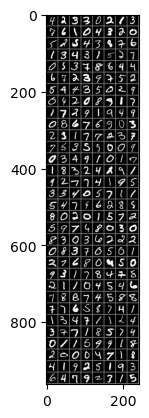

    4     2     3     3     0     2     1     3     7     6     1     0     4     3     2     0     5     2     5     4     3     8     7     6     1     3     4     3     1     5     2     7     0     5     3     7     8     6     4     4     6     7     2     3     9     7     5     2     5     4     4     3     5     0     2     9     0     4     2     0     8     9     1     7     1     7     2     9     1     9     4     9     0     8     6     7     6     9     0     3     2     3     1     7     7     2     3     7     7     5     3     5     5     0     0     9     0     3     4     9     1     0     1     7     1     8     3     2     4     2     9     1     9     2     7     7     4     1     9     5     3     3     4     0     5     7     1     1     5     4     7     9     6     2     8     5     8     0     2     0     1     5     7     2     5     9     7     4     8     0     3     0     8     3     0     3     6     2     2     2     0     8     3     7     0     5     

In [4]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % labels[j].item() for j in range(batch_size)))

<H2>2. Generator</H2>
Lập trình kiến trúc Generator theo mô tả phía dưới

In [5]:
""" Declare GENERATOR. 
    + Its input is a 100-feature vector of random noise
    + Its output is a fake image with pixel values in [-1, 1]"""

class Generator(nn.Module):

    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm1d(512),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm1d(1024),
            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 1, 28, 28)
        return img

G = Generator().to(device)
summary(G, (100,), batch_size=-1, device=str(device))
print("_____________________ Generator Created_____________________")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]          25,856
         LeakyReLU-2                  [-1, 256]               0
       BatchNorm1d-3                  [-1, 256]             512
            Linear-4                  [-1, 512]         131,584
         LeakyReLU-5                  [-1, 512]               0
       BatchNorm1d-6                  [-1, 512]           1,024
            Linear-7                 [-1, 1024]         525,312
         LeakyReLU-8                 [-1, 1024]               0
       BatchNorm1d-9                 [-1, 1024]           2,048
           Linear-10                  [-1, 784]         803,600
             Tanh-11                  [-1, 784]               0
Total params: 1,489,936
Trainable params: 1,489,936
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forw

<H2>3. Discriminator</H2>
Lập trình kiến trúc Discriminator

In [6]:
""" Declare DISCRIMINATOR 
    Its input is REAL IMAGE (in a form of a vector 28x28)
    Its ouput is the probability of image type (REAL IMAGE or FAKE IMAGE)
    the values in the range of [0, 1] """

class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity

D = Discriminator().to(device)
summary(D, (1, height, width), batch_size=-1, device=str(device))
print("____________________ Discriminator Created____________________")


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]         401,920
         LeakyReLU-2                  [-1, 512]               0
            Linear-3                  [-1, 256]         131,328
         LeakyReLU-4                  [-1, 256]               0
            Linear-5                    [-1, 1]             257
Total params: 533,505
Trainable params: 533,505
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.04
Estimated Total Size (MB): 2.05
----------------------------------------------------------------
____________________ Discriminator Created____________________


<h2>4. Generative model</h2>

Xây dựng GAN và huấn luyện

In [7]:
adversarial_loss = torch.nn.BCEWithLogitsLoss()  # dùng với AMP (không Sigmoid ở D)
optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

losses_G = []
losses_D = []
samples = []

use_amp = device.type == 'cuda'
scaler_G = torch.amp.GradScaler('cuda', enabled=use_amp)
scaler_D = torch.amp.GradScaler('cuda', enabled=use_amp)

import time
_p = next(G.parameters())
print('Generator device:', _p.device, '| AMP (mixed precision):', use_amp)
if device.type == 'cuda':
    torch.cuda.synchronize()
    _z = torch.randn(batch_size, 100, device=device)
    t0 = time.time()
    with torch.autocast('cuda', enabled=use_amp):
        for _ in range(50):
            _ = G(_z)
    torch.cuda.synchronize()
    print(f'50 forward G: {time.time() - t0:.2f}s')
    print('VRAM dang dung (MB):', round(torch.cuda.max_memory_allocated() / 1e6, 1))
    torch.cuda.reset_peak_memory_stats()

Generator device: cuda:0 | AMP (mixed precision): True
50 forward G: 0.10s
VRAM dang dung (MB): 23.1


In [8]:
import time
from tqdm.auto import tqdm

print(f'>>> BAT DAU TRAIN: {epochs} epoch | batch={batch_size} | AMP={use_amp}')
print('>>> Neu khong thay gi: doi ~1 epoch dau (co thanh tien trinh ben duoi)')

for epoch in tqdm(range(epochs), desc='Training', unit='epoch'):
    epoch_start = time.time()
    for (i, (imgs, _)) in enumerate(trainloader, start=1):
        valid = torch.ones(imgs.size(0), 1, device=device)
        fake = torch.zeros(imgs.size(0), 1, device=device)
        real_imgs = imgs.to(device, non_blocking=True)

        optimizer_G.zero_grad(set_to_none=True)
        z = torch.randn(imgs.shape[0], 100, device=device)

        with torch.autocast('cuda', enabled=use_amp):
            gen_imgs = G(z)
            g_loss = adversarial_loss(D(gen_imgs), valid)
        scaler_G.scale(g_loss).backward()
        scaler_G.step(optimizer_G)
        scaler_G.update()

        optimizer_D.zero_grad(set_to_none=True)
        with torch.autocast('cuda', enabled=use_amp):
            d_loss = (
                adversarial_loss(D(real_imgs), valid)
                + adversarial_loss(D(gen_imgs.detach()), fake)
            ) / 2
        scaler_D.scale(d_loss).backward()
        scaler_D.step(optimizer_D)
        scaler_D.update()

    if device.type == 'cuda':
        torch.cuda.synchronize()
    sec = time.time() - epoch_start

    if epoch % log_every == 0:
        losses_G.append(g_loss.item())
        losses_D.append(d_loss.item())
        samples.append(gen_imgs.detach().cpu())

    tqdm.write(
        f'Epoch {epoch+1}/{epochs} | D={d_loss.item():.4f} G={g_loss.item():.4f} | {sec:.1f}s'
    )

print('>>> TRAIN XONG!')


>>> BAT DAU TRAIN: 50 epoch | batch=256 | AMP=True
>>> Neu khong thay gi: doi ~1 epoch dau (co thanh tien trinh ben duoi)


Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 | D=0.4182 G=0.8805 | 12.3s
Epoch 2/50 | D=0.6634 G=0.4364 | 12.8s
Epoch 3/50 | D=0.6247 G=0.5760 | 12.7s
Epoch 4/50 | D=0.5795 G=0.9397 | 12.7s
Epoch 5/50 | D=0.6806 G=0.4208 | 13.6s
Epoch 6/50 | D=0.5618 G=0.8357 | 12.4s
Epoch 7/50 | D=0.5515 G=0.8802 | 13.1s
Epoch 8/50 | D=0.5795 G=0.8224 | 13.6s
Epoch 9/50 | D=0.5720 G=0.7424 | 13.7s
Epoch 10/50 | D=0.6698 G=0.4775 | 13.9s
Epoch 11/50 | D=0.6073 G=0.6269 | 13.7s
Epoch 12/50 | D=0.6289 G=0.9726 | 13.7s
Epoch 13/50 | D=0.6334 G=0.9478 | 13.7s
Epoch 14/50 | D=0.6401 G=0.7396 | 13.6s
Epoch 15/50 | D=0.6458 G=0.9577 | 13.8s
Epoch 16/50 | D=0.6238 G=0.8325 | 13.6s
Epoch 17/50 | D=0.6280 G=0.7799 | 13.6s
Epoch 18/50 | D=0.6299 G=0.6923 | 13.7s
Epoch 19/50 | D=0.6202 G=0.8150 | 13.8s
Epoch 20/50 | D=0.6248 G=0.8678 | 13.5s
Epoch 21/50 | D=0.6311 G=0.8695 | 13.7s
Epoch 22/50 | D=0.6276 G=0.7826 | 13.6s
Epoch 23/50 | D=0.6446 G=1.1074 | 13.7s
Epoch 24/50 | D=0.6397 G=1.1297 | 13.7s
Epoch 25/50 | D=0.6392 G=0.7961 | 13.8s
Epoch 26/

### Vẽ đồ thị hàm loss huấn luyện

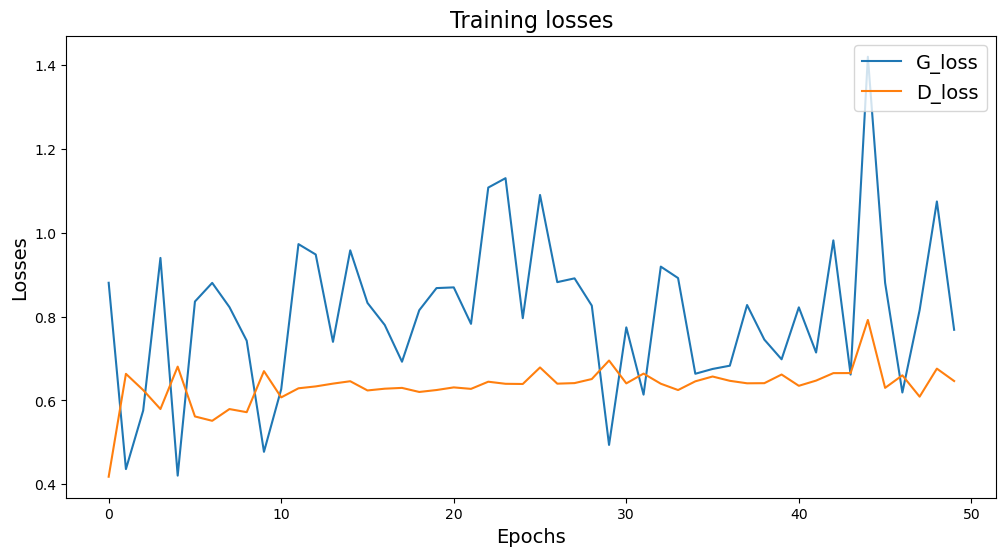

In [9]:
plt.figure(figsize=(12, 6))
epochs_axis = list(range(len(losses_G)))
plt.plot(epochs_axis, losses_G, label="G_loss")
plt.plot(epochs_axis, losses_D, label="D_loss")
plt.title("Training losses", fontsize=16)
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Losses", fontsize=14)
plt.legend(loc="upper right", fontsize=14)
plt.show()

### Trực quan hoá kết quả sinh dữ liệu của mô hình đã huấn luyện

    ____________________ Epoch ~0 ____________________


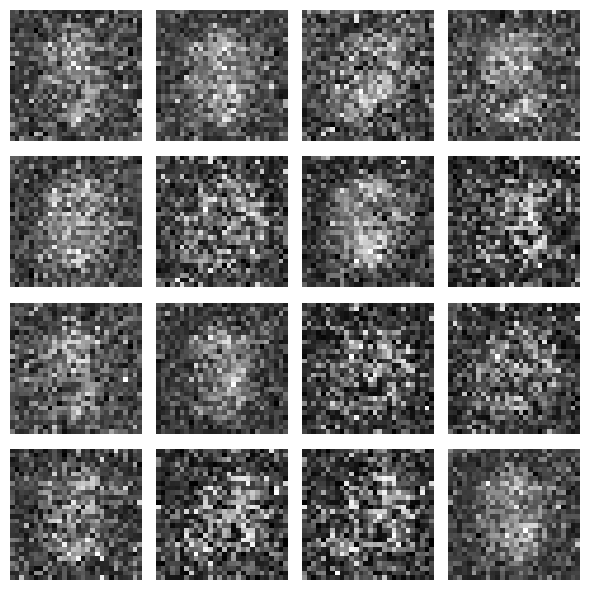



    ____________________ Epoch ~5 ____________________


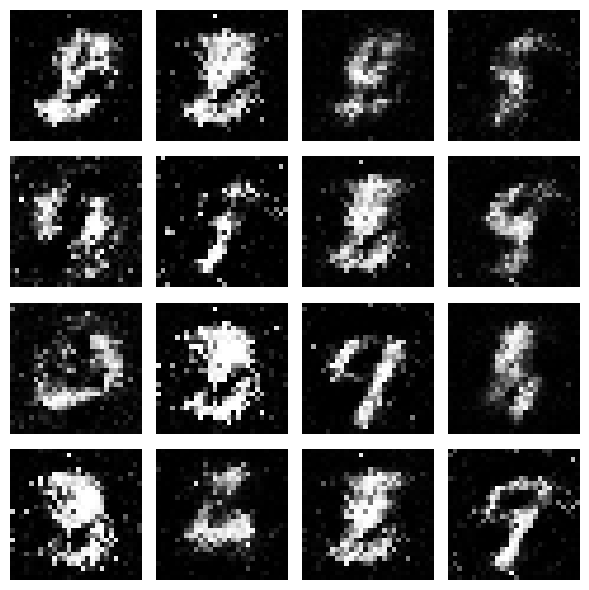



    ____________________ Epoch ~10 ____________________


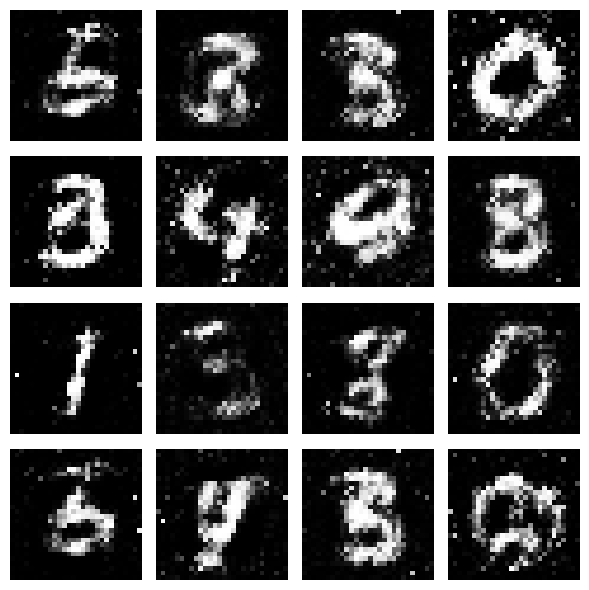



    ____________________ Epoch ~15 ____________________


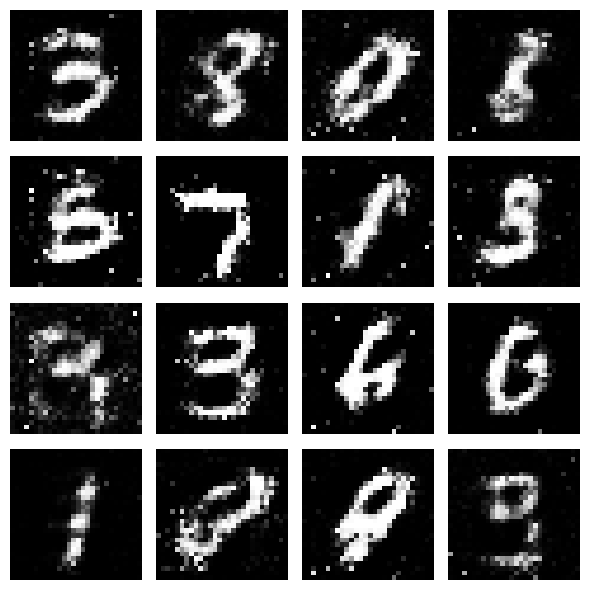



    ____________________ Epoch ~20 ____________________


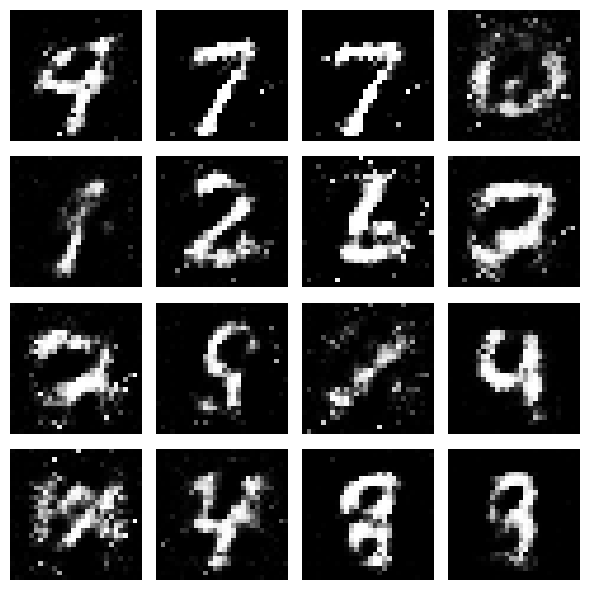



    ____________________ Epoch ~25 ____________________


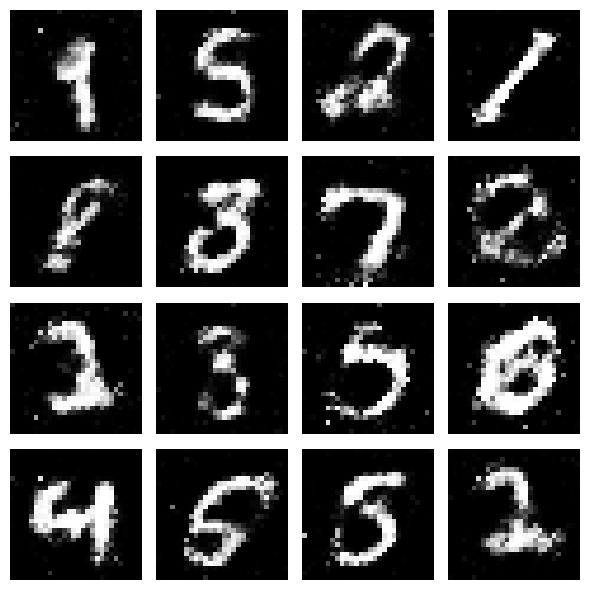



    ____________________ Epoch ~30 ____________________


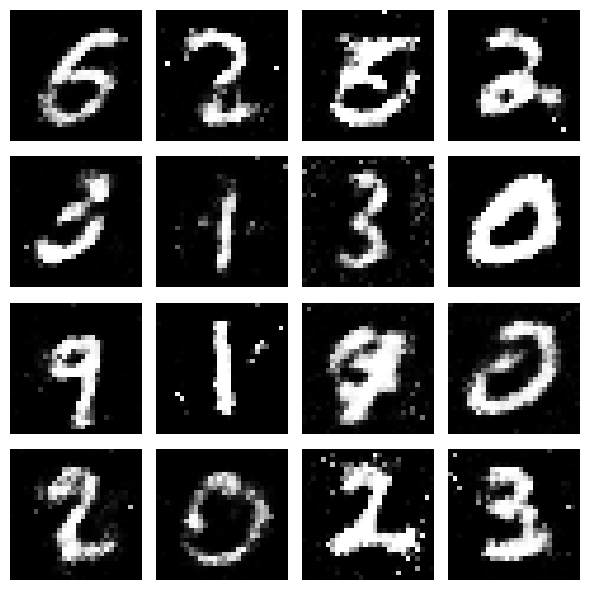



    ____________________ Epoch ~35 ____________________


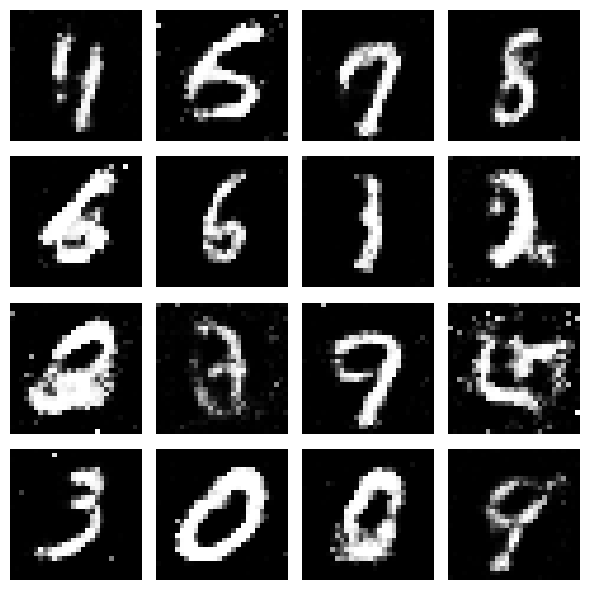



    ____________________ Epoch ~40 ____________________


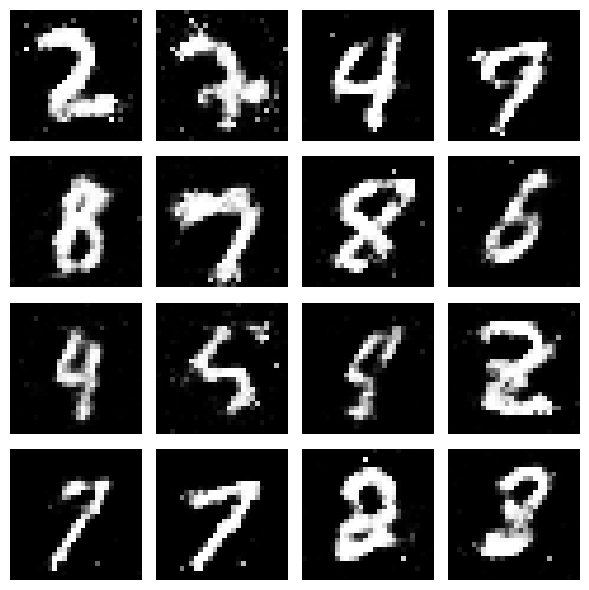



    ____________________ Epoch ~45 ____________________


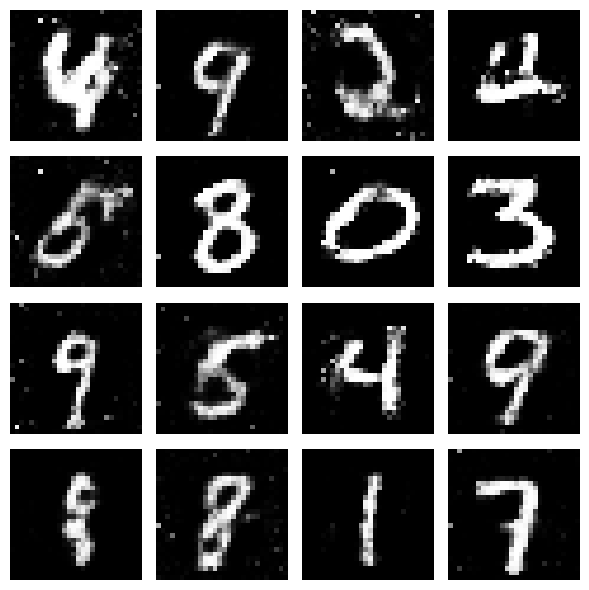

In [10]:
for step in range(0, len(samples), max(1, len(samples) // 10)):
    images = samples[step].numpy()
    print("    ____________________ Epoch ~%d ____________________" % step)
    plt.figure(figsize=(6, 6))
    for j in range(16):
        plt.subplot(4, 4, j + 1)
        image = images[j, :, :, :]
        image = np.reshape(image, [height, width])
        plt.imshow(image, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    print("\n")

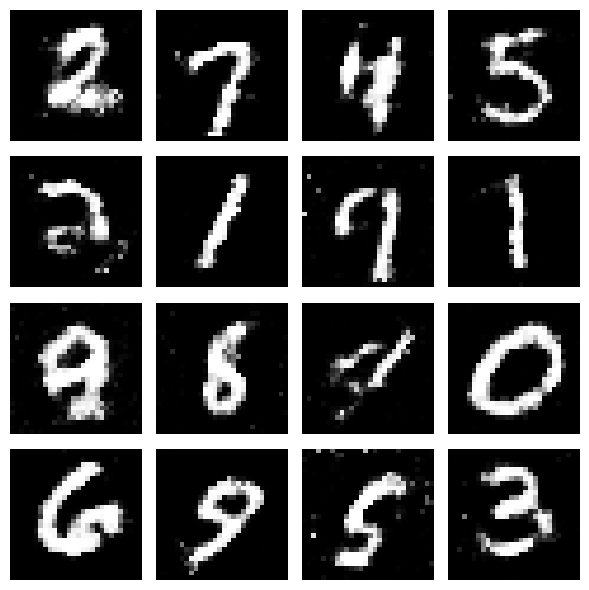

In [11]:
noise = torch.randn(16, 100, device=device)
gen_images = G(noise)
images = gen_images.data.cpu().numpy()
plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i+1)
    image = images[i, :, :, :]
    image = np.reshape(image, [height, width])
    plt.imshow(image, cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()